# 📘 Clase 3: Gradiente Descendente en Regresión Lineal


**Facultad de Ingeniería de la Universidad Nacional de Asunción**  
**Curso:** Inteligencia Artificial 2026  
**Profesores:** Diego Stalder (Teoría) & Christian Torres (Práctica)  

---

## 📌 Objetivos de la Clase

1. Comprender el concepto de gradiente y su interpretación geométrica
2. Entender el algoritmo de Gradiente Descendente para optimización
3. Aplicar Gradiente Descendente a la regresión lineal
4. Diferenciar entre Batch, Mini-batch y SGD
5. Aprender a elegir la tasa de aprendizaje (learning rate)
6. Implementar las diferentes variantes en Python
7. Comparar el método directo (OLS) con el método iterativo (GD)

## 1. 📐 Concepto de Gradiente

### 1.1 Definición Matemática

El **gradiente** de una función $F(w_0, w_1, ..., w_n)$ es un vector que contiene todas las derivadas parciales:

$$ \nabla F = \begin{bmatrix} \frac{\partial F}{\partial w_0} & \frac{\partial F}{\partial w_1} & \cdots & \frac{\partial F}{\partial w_n} \end{bmatrix}^T $$

**Interpretación geométrica:** El gradiente apunta en la dirección de máximo crecimiento de la función. Por lo tanto, para minimizar una función, nos movemos en la dirección **opuesta** al gradiente.

---

### 1.2 Gradiente en Regresión Lineal

Recordemos la función de costo (error cuadrático medio) para regresión lineal. Dada la matriz de diseño $A$ (con una columna de unos para el intercepto) y el vector objetivo $b$:

$$ F(w) = (Aw - b)^T (Aw - b) = \sum_{i=1}^{m} (w^T a^{(i)} - b^{(i)})^2 $$

El gradiente de esta función es:

$$ \nabla F = 2A^T (Aw - b) $$

---

### 1.3 Objetivo de Optimización

Queremos encontrar los parámetros $w$ que minimizan $F(w)$. En la clase anterior vimos la solución analítica (Ecuación Normal):

$$ w = (A^T A)^{-1} A^T b $$

Sin embargo, esta solución tiene limitaciones:
*   Requiere calcular la inversa de $A^TA$, que es $O(n^3)$
*   Para matrices muy grandes, puede ser computacionalmente inviable
*   No escala bien a millones de muestras

Los **métodos iterativos** como el Gradiente Descendente nos permiten optimizar la función de costo de manera más eficiente para grandes volúmenes de datos.

## 2. 🔄 Gradiente Descendente

### 2.1 Algoritmo General

1. Inicializar $w$ aleatoriamente (o con ceros)
2. Para cada iteración hasta convergencia:
   $$ w = w - \eta \nabla F(w) $$
   donde $\eta$ es la **tasa de aprendizaje** (learning rate)

---

### 2.2 Tasa de Aprendizaje ($\eta$)

<img src="https://www.jeremyjordan.me/content/images/2018/02/Screen-Shot-2018-02-24-at-11.47.09-AM.png" width="500">

*   **$\eta$ muy pequeña**: Convergencia lenta, muchas iteraciones necesarias
*   **$\eta$ muy grande**: Puede no converger (oscilar o divergir)
*   **$\eta$ adecuada**: Convergencia rápida y estable hacia el mínimo

---

### 2.3 Criterios de Convergencia

¿Cómo sabemos cuándo detener el algoritmo?

*   **Número fijo de iteraciones**: Simple pero puede ser ineficiente
*   **Cambio en $w$**: $\|w_{t+1} - w_t\| < \epsilon$
*   **Cambio en la función de costo**: $|F(w_{t+1}) - F(w_t)| < \epsilon$
*   **Magnitud del gradiente**: $\|\nabla F(w_t)\| < \epsilon$ (cerca de un punto crítico)

---

### 2.4 Comparación: Método Directo vs Gradiente Descendente

| Característica | Método Directo (OLS) | Gradiente Descendente |
|----------------|----------------------|------------------------|
| **Ventajas** | + Muy simple, solución exacta | + Rápido para matrices grandes<br>+ Eficiente en memoria (SGD)<br>+ Fácil de extender a otros modelos |
| **Desventajas** | - Requiere matriz inversa ($O(n^3)$)<br>- No escala bien | - Requiere ajustar hiperparámetros<br>- Convergencia no garantizada en todos los casos |

## 3. 🧮 Variantes del Gradiente Descendente

### 3.1 Batch Gradient Descent

Usa **todo** el conjunto de datos para calcular el gradiente en cada iteración.

**Ventajas:**
*   Cálculo estable del gradiente (sin ruido)
*   Convergencia suave y predecible

**Desventajas:**
*   Lento para grandes datasets (cada iteración es $O(m \cdot n)$)
*   Requiere que todos los datos quepan en memoria

---

### 3.2 Stochastic Gradient Descent (SGD)

Usa **una sola muestra** aleatoria para calcular el gradiente.

**Ventajas:**
*   Rápido por iteración ($O(n)$ por muestra)
*   Puede escapar de mínimos locales debido al ruido
*   Eficiente en memoria

**Desventajas:**
*   Gradiente muy ruidoso (alta varianza)
*   Convergencia errática, requiere learning rate scheduling

---

### 3.3 Mini-batch Gradient Descent

Usa un **subconjunto pequeño** (batch) de muestras (típicamente 32, 64, 128).

**Ventajas:**
*   Balance entre estabilidad y velocidad
*   Aprovecha operaciones vectorizadas (paralelización)
*   Es el método más utilizado en la práctica (Deep Learning)

**Desventajas:**
*   Requiere ajustar el tamaño del batch como hiperparámetro

---

### 3.4 Comparación Visual

![Comparación de métodos](https://miro.medium.com/v2/resize:fit:1400/1*vshi7PPU30sN3d9bIqH2og.png)

| Método | Tamaño del batch | Ruido en gradiente | Velocidad por iteración | Convergencia |
|--------|------------------|---------------------|-------------------------|--------------|
| Batch | m | Bajo | Lenta | Suave |
| Mini-batch | 16-256 | Medio | Media | Balanceada |
| SGD | 1 | Alto | Rápida | Errágica |

## 4. 📉 Tasa de Aprendizaje y Convergencia

### 4.1 Impacto de la Tasa de Aprendizaje

La elección de la tasa de aprendizaje es crucial para el éxito del algoritmo:

<img src="https://ars.els-cdn.com/content/image/1-s2.0-S0925231220301534-gr5.jpg" width="600">

---

### 4.2 Learning Rate Scheduling

En la práctica, es común **variar la tasa de aprendizaje** durante el entrenamiento:

*   **Exponencial**: $\eta_t = \eta_0 \cdot e^{-kt}$
*   **Step decay**: Reducir cada cierto número de épocas (ej: dividir por 10 cada 30 épocas)
*   **1/t decay**: $\eta_t = \eta_0 / (1 + kt)$

El schedule permite tener pasos grandes al inicio (para avanzar rápido) y pasos pequeños al final (para ajustar fino).

---

### 4.3 Tendencias Actuales

Un hallazgo interesante de investigaciones recientes (Smith et al., Google Brain) es que:

> **"No disminuyas la tasa de aprendizaje, aumenta el tamaño del batch"**

Esto sugiere que aumentar gradualmente el tamaño del batch puede tener un efecto similar a reducir la tasa de aprendizaje, con ventajas en paralelización.

## 5. 📊 Otras Métricas de Evaluación

Para evaluar un modelo de regresión, existen varias métricas comunes:

| Métrica | Fórmula | Descripción |
|---------|---------|-------------|
| **MSE** | $\frac{1}{m}\sum_{i=1}^{m}(y_i - \hat{y}_i)^2$ | Error cuadrático medio (penaliza errores grandes) |
| **RMSE** | $\sqrt{MSE}$ | Raíz del error cuadrático medio (misma unidad que $y$) |
| **MAE** | $\frac{1}{m}\sum_{i=1}^{m}|y_i - \hat{y}_i|$ | Error absoluto medio (robusto a outliers) |
| **R²** | $1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}$ | Coeficiente de determinación (proporción de varianza explicada) |
| **Error Máximo** | $\max_i |y_i - \hat{y}_i|$ | Peor error cometido |

## 6. 💻 Implementación en Python

### 6.1 Configuración Inicial

In [31]:
# Importar librerías necesarias
import numpy as np
import matplotlib.pyplot as plt

# Configuración para gráficos
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

# Semilla para reproducibilidad
np.random.seed(42)

print("Librerías importadas correctamente")

Librerías importadas correctamente


In [32]:
# Generar datos sintéticos
N = 100
x = 2 * np.random.rand(N, 1)
y = 4 + 3 * x + np.random.randn(N, 1)  # Relación real: y = 4 + 3x + ruido

# Construir matriz de diseño (añadir columna de unos)
A = np.c_[np.ones((N, 1)), x]

print(f"Datos generados: {N} muestras")
print(f"Matriz A shape: {A.shape}")
print(f"Vector y shape: {y.shape}")

Datos generados: 100 muestras
Matriz A shape: (100, 2)
Vector y shape: (100, 1)


### 6.2 Batch Gradient Descent

In [33]:
def batch_gradient_descent(A, y, lr=0.1, n_iterations=1000):
    """
    Batch Gradient Descent para regresión lineal
    
    Parámetros:
    - A: matriz de diseño (con columna de unos)
    - y: vector objetivo
    - lr: tasa de aprendizaje
    - n_iterations: número de iteraciones
    
    Retorna:
    - w: coeficientes optimizados
    - history: historial de valores de w
    - mse_history: historial del error cuadrático medio
    """
    m = len(A)
    w = np.random.randn(2, 1)  # Inicialización aleatoria
    history = []
    mse_history = []

    for iteration in range(n_iterations):
        # Calcular gradiente: (2/m) * A.T @ (A @ w - y)
        gradiente = 2/m * A.T.dot(A.dot(w) - y)
        
        # Actualizar parámetros
        w = w - lr * gradiente
        
        # Calcular MSE
        mse = np.mean((A.dot(w) - y) ** 2)
        mse_history.append(mse)
        
        # Guardar historial cada 10 iteraciones
        if iteration % 10 == 0:
            history.append(w.copy())
    
    return w, np.array(history), mse_history

# Ejecutar Batch GD
w_batch, hist_batch, mse_batch = batch_gradient_descent(A, y, lr=0.1, n_iterations=1000)

print("Coeficientes encontrados (Batch GD):")
print(f"w_0 (intercepto) = {w_batch[0][0]:.4f}")
print(f"w_1 (pendiente)  = {w_batch[1][0]:.4f}")
print("\nValores reales: w_0=4, w_1=3")

Coeficientes encontrados (Batch GD):
w_0 (intercepto) = 4.2151
w_1 (pendiente)  = 2.7701

Valores reales: w_0=4, w_1=3


### 6.3 Visualización del Proceso de Descenso

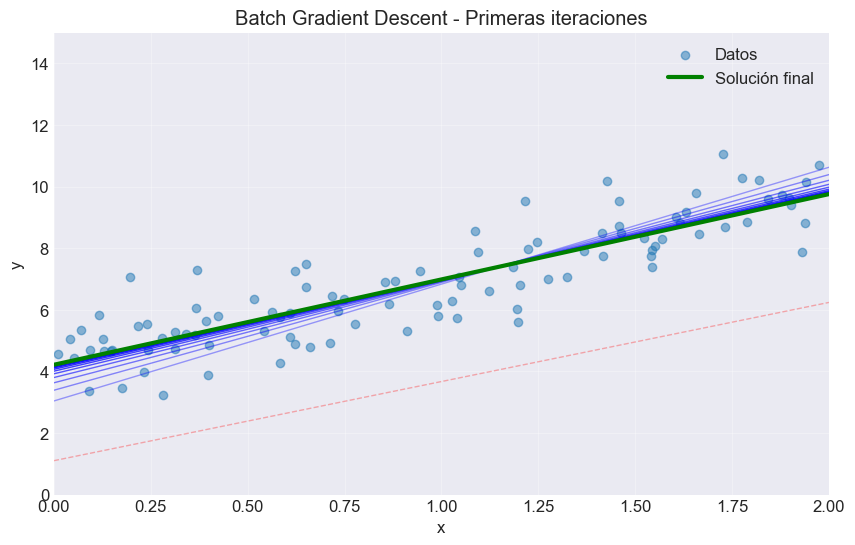

In [34]:
def plot_gradient_descent_steps(A, y, w_history, title):
    """
    Visualiza las primeras iteraciones del gradiente descendente
    """
    X_plot = np.array([[0], [2]])
    X_plot_b = np.c_[np.ones((2, 1)), X_plot]

    plt.figure(figsize=(10, 6))
    plt.scatter(A[:, 1], y, alpha=0.5, label='Datos')

    # Mostrar solo las primeras 10 iteraciones
    for i, w in enumerate(w_history[:10]):
        y_pred = X_plot_b.dot(w)
        style = 'r--' if i == 0 else 'b-'
        alpha = 0.3 + 0.7 * (i / 10)
        plt.plot(X_plot, y_pred, style, alpha=alpha, linewidth=1)

    # Recta final
    w_final = w_history[-1]
    y_final = X_plot_b.dot(w_final)
    plt.plot(X_plot, y_final, 'g-', linewidth=3, label='Solución final')

    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.axis([0, 2, 0, 15])
    plt.show()

plot_gradient_descent_steps(A, y, hist_batch, "Batch Gradient Descent - Primeras iteraciones")

### 6.4 Efecto de la Tasa de Aprendizaje

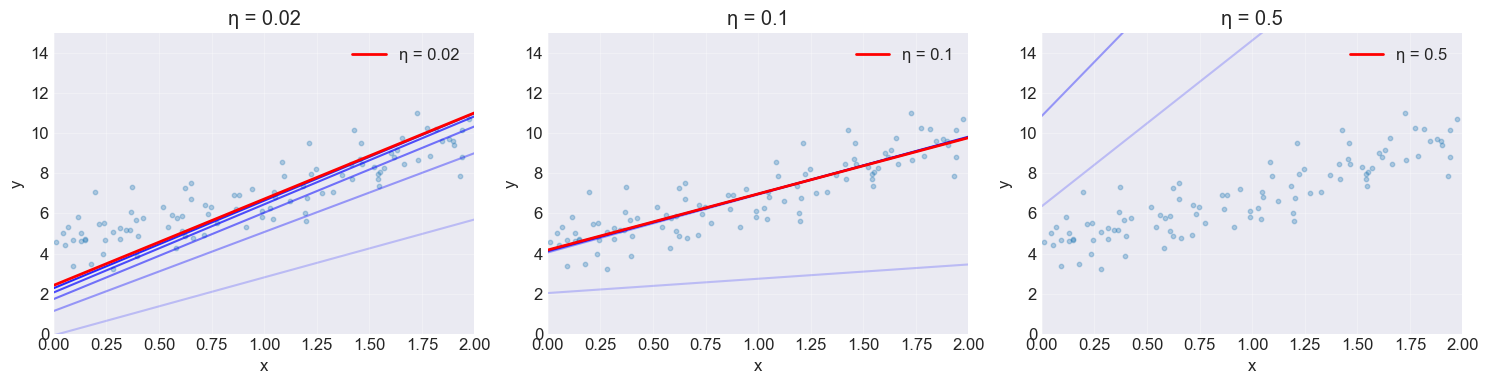

In [35]:
def compare_learning_rates(A, y, learning_rates):
    """
    Compara diferentes tasas de aprendizaje
    """
    plt.figure(figsize=(15, 4))

    for i, lr in enumerate(learning_rates):
        w, hist, mse = batch_gradient_descent(A, y, lr=lr, n_iterations=50)

        plt.subplot(1, len(learning_rates), i+1)
        plt.scatter(A[:, 1], y, alpha=0.3, s=10)

        X_plot = np.array([[0], [2]])
        X_plot_b = np.c_[np.ones((2, 1)), X_plot]

        # Mostrar iteraciones
        for j, w_i in enumerate(hist[:5]):
            y_pred = X_plot_b.dot(w_i)
            alpha = 0.2 + 0.8 * (j / 5)
            plt.plot(X_plot, y_pred, 'b-', alpha=alpha)

        # Solución final
        y_final = X_plot_b.dot(w)
        plt.plot(X_plot, y_final, 'r-', linewidth=2, label=f'η = {lr}')

        plt.xlabel('x')
        plt.ylabel('y')
        plt.title(f'η = {lr}')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.axis([0, 2, 0, 15])

    plt.tight_layout()
    plt.show()

# Probar diferentes learning rates
compare_learning_rates(A, y, [0.02, 0.1, 0.5])

### 6.5 Stochastic Gradient Descent (SGD)

Coeficientes encontrados (SGD):
w_0 = 4.1791
w_1 = 2.7263


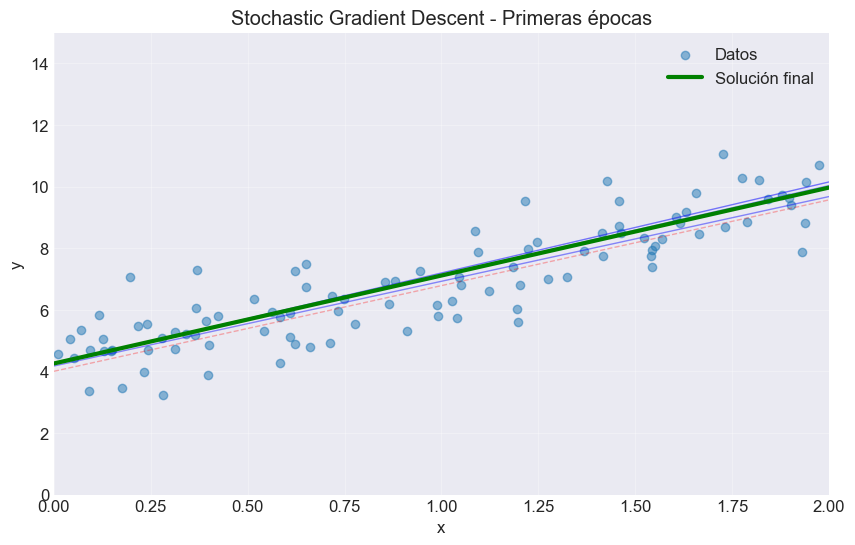

In [36]:
def stochastic_gradient_descent(A, y, n_epochs=50, initial_lr=0.1):
    """
    Stochastic Gradient Descent con learning rate schedule
    
    El SGD actualiza los pesos usando UNA SOLA muestra aleatoria en cada paso.
    Esto introduce ruido en el gradiente pero es muy eficiente en memoria.
    """
    m = len(A)
    w = np.random.randn(2, 1)
    history = []
    mse_history = []

    def learning_schedule(t, t0=5, t1=50):
        return t0 / (t + t1)

    t = 0
    for epoch in range(n_epochs):
        for i in range(m):
            # Seleccionar una muestra aleatoria
            random_index = np.random.randint(m)
            xi = A[random_index:random_index+1]
            yi = y[random_index:random_index+1]

            # Calcular gradiente para una muestra
            gradiente = 2 * xi.T.dot(xi.dot(w) - yi)

            # Actualizar learning rate (disminuye con el tiempo)
            eta = learning_schedule(t)
            t += 1

            # Actualizar parámetros
            w = w - eta * gradiente

        # Calcular MSE al final de cada época
        mse = np.mean((A.dot(w) - y) ** 2)
        mse_history.append(mse)
        
        if epoch < 5:  # Guardar solo primeras épocas para visualización
            history.append(w.copy())

    return w, np.array(history), mse_history

# Ejecutar SGD
w_sgd, hist_sgd, mse_sgd = stochastic_gradient_descent(A, y)

print("Coeficientes encontrados (SGD):")
print(f"w_0 = {w_sgd[0][0]:.4f}")
print(f"w_1 = {w_sgd[1][0]:.4f}")

# Visualizar
plot_gradient_descent_steps(A, y, hist_sgd, "Stochastic Gradient Descent - Primeras épocas")

### 6.6 Mini-batch Gradient Descent

Coeficientes encontrados (Mini-batch GD):
w_0 = 4.2386
w_1 = 2.7991


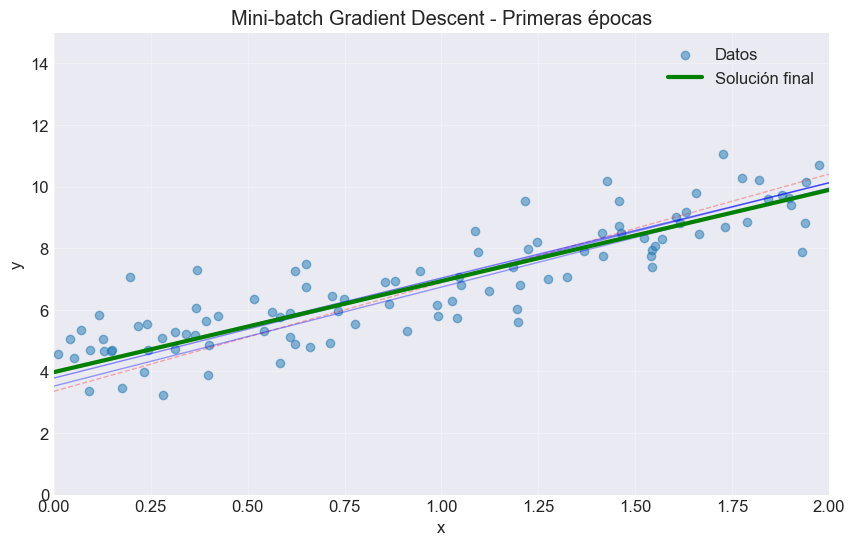

In [37]:
def minibatch_gradient_descent(A, y, batch_size=20, n_epochs=50):
    """
    Mini-batch Gradient Descent
    
    Usa un subconjunto de muestras (batch) para cada actualización.
    Balance entre la estabilidad de Batch GD y la eficiencia de SGD.
    """
    m = len(A)
    w = np.random.randn(2, 1)
    history = []
    mse_history = []

    def learning_schedule(t, t0=200, t1=1000):
        return t0 / (t + t1)

    t = 0
    for epoch in range(n_epochs):
        # Mezclar datos (importante para mini-batch)
        shuffled_indices = np.random.permutation(m)
        A_shuffled = A[shuffled_indices]
        y_shuffled = y[shuffled_indices]

        for i in range(0, m, batch_size):
            xi = A_shuffled[i:i+batch_size]
            yi = y_shuffled[i:i+batch_size]

            gradiente = 2/batch_size * xi.T.dot(xi.dot(w) - yi)

            eta = learning_schedule(t)
            t += 1

            w = w - eta * gradiente

        # Calcular MSE al final de cada época
        mse = np.mean((A.dot(w) - y) ** 2)
        mse_history.append(mse)
        
        if epoch < 5:
            history.append(w.copy())

    return w, np.array(history), mse_history

# Ejecutar Mini-batch GD
w_mini, hist_mini, mse_mini = minibatch_gradient_descent(A, y)

print("Coeficientes encontrados (Mini-batch GD):")
print(f"w_0 = {w_mini[0][0]:.4f}")
print(f"w_1 = {w_mini[1][0]:.4f}")

plot_gradient_descent_steps(A, y, hist_mini, "Mini-batch Gradient Descent - Primeras épocas")

### 6.7 Comparación de la Evolución del Error

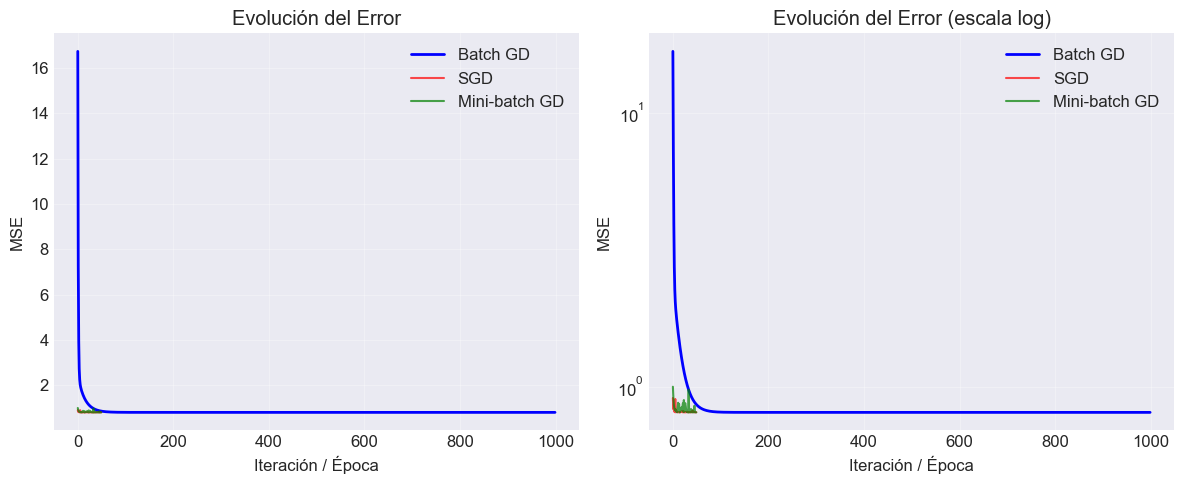

Observaciones:
- Batch GD: convergencia suave pero lenta por iteración
- SGD: convergencia ruidosa pero rápida por muestra
- Mini-batch: balance entre ambos


In [38]:
# Re-ejecutar para obtener historiales completos
_, _, mse_batch_full = batch_gradient_descent(A, y, lr=0.1, n_iterations=1000)
_, _, mse_sgd_full = stochastic_gradient_descent(A, y, n_epochs=50)
_, _, mse_mini_full = minibatch_gradient_descent(A, y)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(mse_batch_full, 'b-', label='Batch GD', linewidth=2)
plt.plot(mse_sgd_full, 'r-', alpha=0.7, label='SGD', linewidth=1.5)
plt.plot(mse_mini_full, 'g-', alpha=0.7, label='Mini-batch GD', linewidth=1.5)
plt.xlabel('Iteración / Época')
plt.ylabel('MSE')
plt.title('Evolución del Error')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(mse_batch_full, 'b-', label='Batch GD', linewidth=2)
plt.plot(mse_sgd_full, 'r-', alpha=0.7, label='SGD', linewidth=1.5)
plt.plot(mse_mini_full, 'g-', alpha=0.7, label='Mini-batch GD', linewidth=1.5)
plt.xlabel('Iteración / Época')
plt.ylabel('MSE')
plt.title('Evolución del Error (escala log)')
plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Observaciones:")
print("- Batch GD: convergencia suave pero lenta por iteración")
print("- SGD: convergencia ruidosa pero rápida por muestra")
print("- Mini-batch: balance entre ambos")

### 6.8 Comparación de Trayectorias en el Espacio de Parámetros

h:\Anaconda\envs\deepf\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
h:\Anaconda\envs\deepf\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


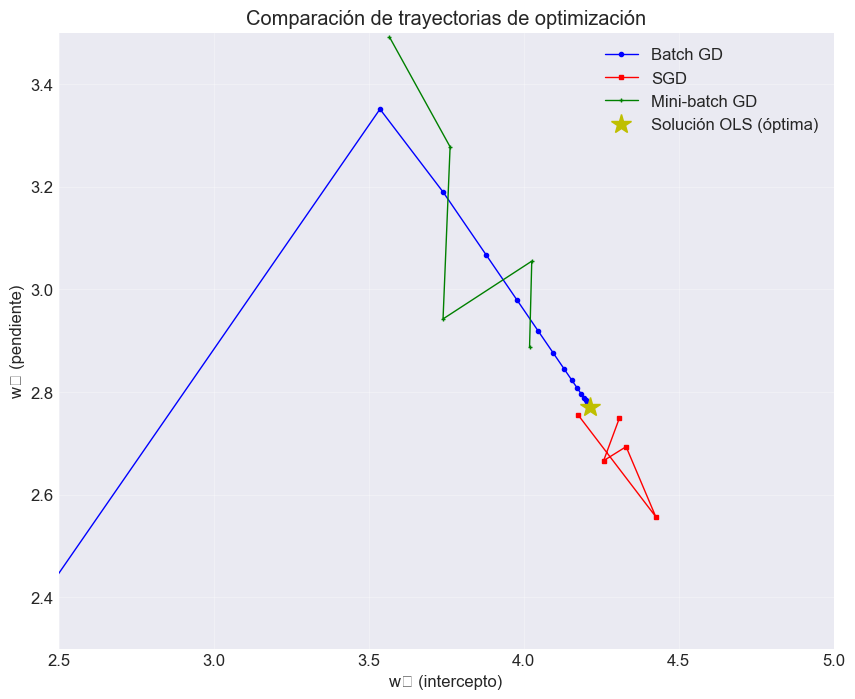

In [39]:
# Recolectar trayectorias para comparación
w_batch_full, hist_batch_full, _ = batch_gradient_descent(A, y, lr=0.1, n_iterations=200)
w_sgd_full, hist_sgd_full, _ = stochastic_gradient_descent(A, y, n_epochs=20)
w_mini_full, hist_mini_full, _ = minibatch_gradient_descent(A, y, n_epochs=20)

plt.figure(figsize=(10, 8))

# Graficar trayectorias en el espacio de parámetros
plt.plot(hist_batch_full[:, 0], hist_batch_full[:, 1], 'b-o', linewidth=1, markersize=3, label='Batch GD')
plt.plot(hist_sgd_full[:, 0], hist_sgd_full[:, 1], 'r-s', linewidth=1, markersize=3, label='SGD')
plt.plot(hist_mini_full[:, 0], hist_mini_full[:, 1], 'g-+', linewidth=1, markersize=3, label='Mini-batch GD')

# Solución óptima (OLS)
w_ols = np.linalg.inv(A.T.dot(A)).dot(A.T).dot(y)
plt.plot(w_ols[0], w_ols[1], 'y*', markersize=15, label='Solución OLS (óptima)')

plt.xlabel('w₀ (intercepto)')
plt.ylabel('w₁ (pendiente)')
plt.title('Comparación de trayectorias de optimización')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis([2.5, 5, 2.3, 3.5])
plt.show()

## 7. 📝 Ejercicios Propuestos

### Ejercicio 1: Implementación desde cero

Implementa tu propia función de gradiente descendente que:
*   Permita elegir entre batch, SGD y mini-batch mediante un parámetro
*   Almacene el historial de la función de costo
*   Grafique la convergencia para diferentes learning rates

### Ejercicio 2: Learning Rate Scheduling

Investiga e implementa diferentes estrategias de ajuste de learning rate:
*   Exponencial: $\eta_t = \eta_0 \cdot e^{-kt}$
*   Step decay: reducir cada cierto número de épocas
*   1/t decay: $\eta_t = \eta_0 / (1 + kt)$

Compara su rendimiento en términos de velocidad de convergencia y estabilidad.

### Ejercicio 3: Comparación con Scikit-learn

Usa `SGDRegressor` de scikit-learn para resolver el mismo problema. Compara:
*   Los coeficientes obtenidos
*   El número de iteraciones necesarias
*   La evolución de la función de costo

```python
from sklearn.linear_model import SGDRegressor

sgd_reg = SGDRegressor(max_iter=1000, tol=1e-3, penalty=None, eta0=0.1, learning_rate='constant')
sgd_reg.fit(A[:, 1:], y.ravel())  # A[:, 1:] son las features (sin la columna de unos)
```

### Ejercicio 4: Visualización 3D de la Función de Costo

Para la regresión lineal simple (2 parámetros), la función de costo $F(w_0, w_1)$ se puede visualizar en 3D. Genera una malla de valores para $w_0$ y $w_1$, calcula el costo y crea un gráfico de superficie. Marca la trayectoria del gradiente descendente.

C:\Users\yoda\AppData\Local\Temp\ipykernel_9056\2679146405.py:49: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\yoda\AppData\Local\Temp\ipykernel_9056\2679146405.py:49: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()


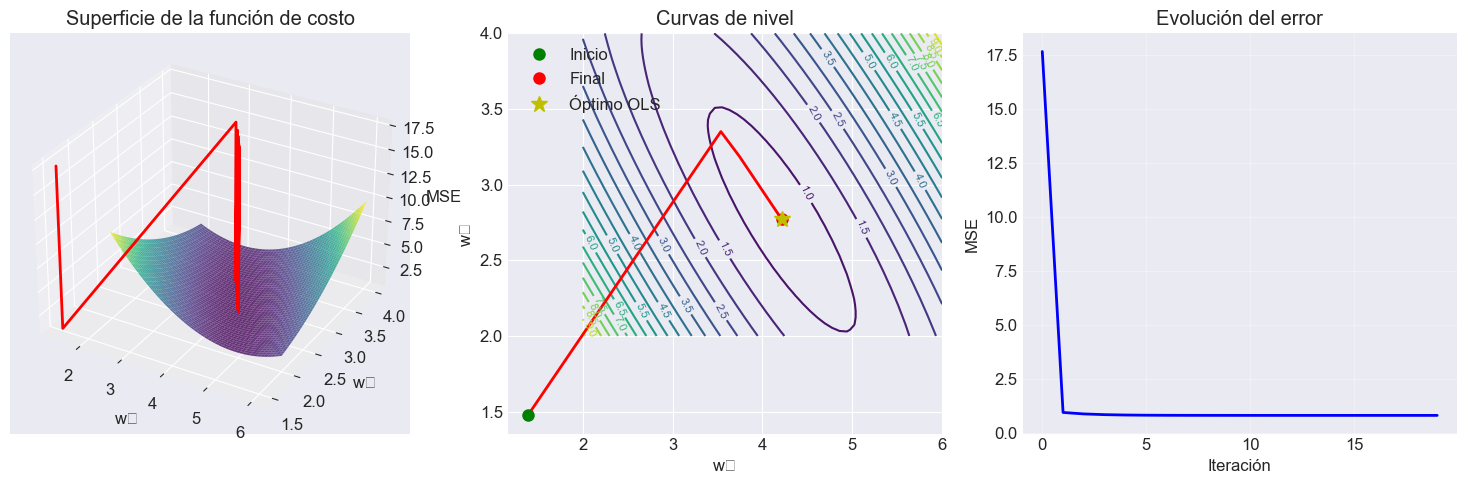

In [40]:
# Ejemplo de visualización 3D (solución al ejercicio 4)
from mpl_toolkits.mplot3d import Axes3D

# Crear malla de valores
w0_vals = np.linspace(2, 6, 50)
w1_vals = np.linspace(2, 4, 50)
W0, W1 = np.meshgrid(w0_vals, w1_vals)
J_vals = np.zeros(W0.shape)

# Calcular costo para cada combinación
for i in range(len(w0_vals)):
    for j in range(len(w1_vals)):
        w = np.array([[W0[i, j]], [W1[i, j]]])
        J_vals[i, j] = np.mean((A.dot(w) - y) ** 2)

fig = plt.figure(figsize=(15, 5))

ax1 = fig.add_subplot(1, 3, 1, projection='3d')
ax1.plot_surface(W0, W1, J_vals, cmap='viridis', alpha=0.8)
ax1.set_xlabel('w₀')
ax1.set_ylabel('w₁')
ax1.set_zlabel('MSE')
ax1.set_title('Superficie de la función de costo')

# Agregar trayectoria del gradiente
mse_trayectoria = [np.mean((A.dot(w.reshape(-1,1)) - y) ** 2) for w in hist_batch_full]
ax1.plot(hist_batch_full[:, 0], hist_batch_full[:, 1], mse_trayectoria, 
         'r-', linewidth=2, label='Trayectoria GD')

ax2 = fig.add_subplot(1, 3, 2)
contour = ax2.contour(W0, W1, J_vals, levels=20, cmap='viridis')
ax2.clabel(contour, inline=True, fontsize=8)
ax2.plot(hist_batch_full[:, 0], hist_batch_full[:, 1], 'r-', linewidth=2)
ax2.plot(hist_batch_full[0, 0], hist_batch_full[0, 1], 'go', markersize=8, label='Inicio')
ax2.plot(hist_batch_full[-1, 0], hist_batch_full[-1, 1], 'ro', markersize=8, label='Final')
ax2.plot(w_ols[0], w_ols[1], 'y*', markersize=12, label='Óptimo OLS')
ax2.set_xlabel('w₀')
ax2.set_ylabel('w₁')
ax2.set_title('Curvas de nivel')
ax2.legend()

ax3 = fig.add_subplot(1, 3, 3)
ax3.plot(mse_trayectoria, 'b-', linewidth=2)
ax3.set_xlabel('Iteración')
ax3.set_ylabel('MSE')
ax3.set_title('Evolución del error')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. 📚 Recursos Adicionales

*   🔗 [Gradient Descent - Andrew Ng (Video)](https://www.youtube.com/watch?v=jc2IthslyzM)
*   🔗 [Understanding the Mathematics of Gradient Descent](https://towardsdatascience.com/understanding-the-mathematics-behind-gradient-descent-dde5dc9be06e)
*   🔗 [Scikit-learn SGD Regressor Documentation](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDRegressor.html)
*   🔗 [An overview of gradient descent optimization algorithms](https://www.ruder.io/optimizing-gradient-descent/)
*   🔗 [Don't decay the learning rate, increase the batch size (Smith et al., Google Brain)](https://arxiv.org/abs/1711.00489)

---
